In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
train = pd.read_csv("../data/predtrain.csv")
test = pd.read_csv("../data/predtest.csv")
submission = pd.read_csv("../data/sample_submission.csv")

In [3]:
train.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
print("The train data shape is {}".format(train.shape))
print("The test data shape is {}".format(test.shape))

The train data shape is (594194, 21)
The test data shape is (254655, 20)


In [5]:
remove_features=['id']
train=train.drop(['id'],axis=1)
test=test.drop(['id'],axis=1)

In [6]:
train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,Yes,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,Female,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [7]:
test.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55
3,Male,0,Yes,Yes,71,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),84.10,6457.15
4,Female,0,No,No,15,Yes,No,Fiber optic,Yes,No,No,No,Yes,Yes,Month-to-month,No,Electronic check,90.35,1233.65


## Target Dstribution

In [8]:
train["Churn"].value_counts()

Churn
No     460377
Yes    133817
Name: count, dtype: int64

In [9]:
status_counts = train["Churn"].value_counts()
labels = status_counts.index
sizes = status_counts.values

In [10]:
status_counts

Churn
No     460377
Yes    133817
Name: count, dtype: int64

In [11]:
labels

Index(['No', 'Yes'], dtype='str', name='Churn')

In [12]:
sizes

array([460377, 133817])

In [13]:
# Calcula
percentages = 100.*sizes/sizes.sum()

In [14]:
percentages

array([77.47924079, 22.52075921])

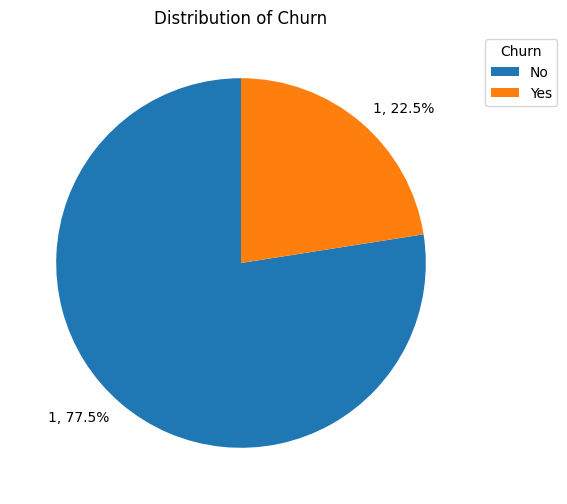

In [15]:
plt.figure(figsize=(10,6))
plt.pie(sizes, labels=[f"{1}, {s:.1f}%" for l, s in zip(labels, percentages)], startangle=90)
plt.gca().set_aspect("equal")
plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1), labels=labels, title="Churn")
plt.title(f"Distribution of Churn")
plt.show()

In [16]:
mapping = {'No':0, "Yes":1}
train['Churn'] = train['Churn'].map(mapping)

### Unique & Missing Values

In [17]:
pip install prettytable

  Using cached prettytable-3.17.0-py3-none-any.whl.metadata (34 kB)
Using cached prettytable-3.17.0-py3-none-any.whl (34 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
from prettytable import PrettyTable

In [19]:
target = 'Churn'
train_copy = train.copy()
test_copy = test.copy()

In [20]:
table = PrettyTable()

table.field_names = ['Feature', 'Data Type', 'Train Missing %', 'Test Missing %']

for column in train_copy.columns:
    data_type = str(train_copy[column].dtype)
    non_null_count_train = np.round(100-train_copy[column].count()/train_copy.shape[0]*100, 1)
    if column != target:
        non_null_count_test = np.round(100-test_copy[column].count()/test_copy.shape[0]*100,1)
    else:
        non_null_count_test="NA"

    table.add_row([column, data_type, non_null_count_train, non_null_count_test])
print(table)

+------------------+-----------+-----------------+----------------+
|     Feature      | Data Type | Train Missing % | Test Missing % |
+------------------+-----------+-----------------+----------------+
|      gender      |    str    |       0.0       |      0.0       |
|  SeniorCitizen   |   int64   |       0.0       |      0.0       |
|     Partner      |    str    |       0.0       |      0.0       |
|    Dependents    |    str    |       0.0       |      0.0       |
|      tenure      |   int64   |       0.0       |      0.0       |
|   PhoneService   |    str    |       0.0       |      0.0       |
|  MultipleLines   |    str    |       0.0       |      0.0       |
| InternetService  |    str    |       0.0       |      0.0       |
|  OnlineSecurity  |    str    |       0.0       |      0.0       |
|   OnlineBackup   |    str    |       0.0       |      0.0       |
| DeviceProtection |    str    |       0.0       |      0.0       |
|   TechSupport    |    str    |       0.0      